# W4D3 — Flood Segmentation with U-Net — Lab

**Week 4 · Day 3 · CNNs & Model Fine-Tuning** · Lab

> **The big idea.** A **classifier** gives you one label per image (*"this is flooded"*).
> A **detector** gives you one box per object (*"the car is here"*). A **segmenter**
> gives you one label per **pixel** (*"these exact pixels are water; the rest are dry
> ground, houses, cars, trees"*). Same input image, three completely different outputs
> — and the one you pick decides which network architecture you need. Today you build
> the segmenter.

The architecture that made segmentation practical is called **U-Net** — a CNN with an
encoder that shrinks the image into features (like every network you've built this
week), plus a mirror-image **decoder** that grows those features back up to pixel-level
predictions. The two halves are stitched together with **skip connections**, so the
decoder can see fine details the encoder would otherwise lose. The result: one 128×128
prediction mask per input image, one class per pixel.

**Why flood?** Because segmentation is where CNNs stop being a classroom exercise and
start saving lives. A flood map built from aerial or satellite imagery tells rescue
teams which streets are passable in the first hours after a storm, where to drop
supplies, which neighbourhoods to evacuate. The 2022 Jeddah floods and the 2024 UAE
floods both used models with the same architecture you'll build today.

You will **not** write U-Net from scratch — the architecture is standard enough that a
library (`segmentation_models_pytorch`) gives it to you in one line. What you *will*
write is everything around it: the data pipeline that pairs photos with their flood
masks, the loss that compares predictions to ground truth per-pixel, the training
loop, and the evaluation metric (**IoU**) that tells you how much of the actual water
you caught.

**Three things, in order:**

- **Load the data.** The Kaggle flood dataset ships as plain folders — `Image/` of
  flood photos and `Mask/` of hand-painted binary ground-truth masks. You'll pair them
  up and verify by eye.
- **Train a pretrained U-Net.** `smp.Unet` with a `resnet18` encoder loaded from
  ImageNet weights — ~14M parameters that already know what edges and textures look
  like. 5 epochs on CPU on the 290-image dataset.
- **Measure IoU and look at predictions.** Numbers matter, but a wrong flood mask
  always tells you *why*. Pick the three best and three worst and read what the model
  saw — or missed.

**Time budget:** ~115 minutes · Section 1 warm-up (20 min) · Section 2 tasks (70 min) ·
Section 3 stretch (25 min).

<div dir="rtl" align="right">

# الأسبوع ٤ · اليوم ٣ — تجزئة مناطق الفيضانات بـU-Net

**الأسبوع الرابع · اليوم الثالث · الشبكات الالتفافية وضبط النماذج** · معمل

> **الفكرة الكبرى.** يُعطيك **المصنِّف** عنوانًا واحدًا لكل صورة (*«هذه مغمورة بالمياه»*).
> ويعطيك **الكاشف** صندوقًا واحدًا لكل كائن (*«السيّارة هنا»*). ويعطيك **المُجزِّئ**
> عنوانًا لكل **بكسل** (*«هذه البكسلات بالضبط ماء، والباقي أرض يابسة وبيوت وسيّارات
> وأشجار»*). الصورة نفسها دخلًا، وثلاثة مخرجات مختلفة تمامًا — والذي تختاره يُحدِّد
> المعمارية التي تحتاجها. اليوم تبني المُجزِّئ.

والمعمارية التي جعلت التجزئة ممكنة اسمها **U-Net** — شبكة التفافية فيها مُرمِّز
يُصغِّر الصورة إلى سمات (كما في كل شبكة بنيتَها هذا الأسبوع)، مع **مُفكِّك** مرآتيّ
يُعيد تكبير تلك السمات إلى تنبّؤات على مستوى البكسل. ويُوصَل النصفان بـ**وصلات تخطّي**،
فيرى المُفكِّك التفاصيل الدقيقة التي كان المُرمِّز سيُضيّعها. والنتيجة: قناع تنبّؤ
١٢٨×١٢٨ لكل صورة دخل، وفئة واحدة لكل بكسل.

**لماذا الفيضانات؟** لأن التجزئة هي حيث تتوقّف الشبكات الالتفافية عن كونها تمرينًا صفّيًا
وتبدأ في إنقاذ الأرواح. خريطة فيضان مبنية من صور جوّية أو من الأقمار الاصطناعية تخبر
فرق الإنقاذ أي الشوارع سالك في الساعات الأولى بعد عاصفة، وأين تُسقِط الإمدادات، وأي
الأحياء تُخلي. فيضانات جدّة ٢٠٢٢ وفيضانات الإمارات ٢٠٢٤ استعملت نماذج بالمعمارية
نفسها التي ستبنيها اليوم.

ولن **تكتب** U-Net من الصفر — المعمارية قياسية بما يكفي ليعطيكها سطرٌ واحد من مكتبة
(`segmentation_models_pytorch`). الذي **ستكتبه** هو كل ما حولها: خطّ البيانات الذي
يُقرِن الصور بأقنعتها، والخسارة التي تقارن التنبّؤات بالحقيقة بكسلًا بكسلًا، وحلقة
التدريب، ومقياس التقييم **IoU** الذي يقول لك كم من الماء الحقيقي أمسكت.

**ثلاثة أشياء بالترتيب:**

- **حمِّل البيانات.** مجموعة Kaggle للفيضانات تأتي بمجلّدات بسيطة — `Image/` لصور
  الفيضانات و`Mask/` لأقنعة ثنائية رُسمت باليد. ستقرن بينهما وتتحقّق منها بعينيك.
- **درِّب U-Net مُدرَّبًا مسبقًا.** `smp.Unet` بمُرمِّز `resnet18` محمَّل بأوزان
  ImageNet — نحو ١٤ مليون معامل تعرف أصلًا ما هي الحواف والمَلامس. ٥ حقب على CPU
  على ٢٩٠ صورة.
- **اقِس IoU وانظر إلى التنبّؤات.** الأرقام مهمّة، لكنّ قناع الفيضان الخاطئ يقول
  لك *لماذا*. اختر الأفضل الثلاثة والأسوأ الثلاثة واقرأ ما رآه النموذج — أو ما فاته.

**الزمن المتوقّع:** نحو ١١٥ دقيقة · القسم ١ الإحماء (٢٠ د) · القسم ٢ المهامّ (٧٠ د) ·
القسم ٣ الإضافي (٢٥ د).

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

The point of today is to make you fluent with the per-pixel view of a CNN. By the end
you can read any segmentation paper and know what the architecture is doing, what the
loss is punishing, and why IoU is the number everyone quotes.

Concretely, you can:

- Explain in one sentence what makes U-Net different from a classification CNN
  (the decoder, the skip connections, and the per-pixel output).
- Pair an image with its segmentation mask inside a `Dataset`, and apply resize +
  tensor conversion that keeps the two aligned.
- Load a `smp.Unet` with a pretrained ResNet-18 encoder in one line, and read
  `torchinfo.summary` to see the encoder-decoder shape.
- Train with `nn.BCEWithLogitsLoss` on binary masks, and say why we use it instead of
  cross-entropy here.
- Compute **IoU** between a predicted flood mask and the ground truth, and say what
  IoU=0.75 means in terms of pixels of water correctly identified.
- Pick the three worst predictions and name their failure mode (reflections, shadows,
  roads that look like rivers, flooded building roofs the model missed).
- **Stretch — Dice loss:** swap BCE for Dice and read whether the gap is real.
- **Stretch — Augmentation for segmentation:** apply horizontal flip to the training
  data and discover the trap specific to segmentation — the mask must flip too.

<div dir="rtl" align="right">

## أهداف التعلّم

مقصد اليوم أن تصير متمكِّنًا من رؤية الشبكة الالتفافية بكسلًا بكسلًا. في نهايته تستطيع
قراءة أي بحث تجزئة ومعرفة ما تفعله المعمارية، وما تعاقبه الخسارة، ولماذا IoU هو الرقم
الذي يذكره الجميع.

وبالتحديد تستطيع:

- أن تشرح في جملة واحدة ما الذي يُميِّز U-Net عن شبكة تصنيف (المُفكِّك ووصلات التخطّي
  والخرج بكسلًا بكسلًا).
- أن تُقرِن صورة بقناعها داخل `Dataset`، وتُطبّق تحجيمًا وتحويلًا إلى موتِّر يُبقيهما
  متوافقَين.
- أن تُحمِّل `smp.Unet` بمُرمِّز `resnet18` مُدرَّب مسبقًا بسطر واحد، وتقرأ
  `torchinfo.summary` لترى شكل المُرمِّز-المُفكِّك.
- أن تُدرِّب بـ`nn.BCEWithLogitsLoss` على أقنعة ثنائية، وتقول لماذا نستعملها هنا بدل
  cross-entropy.
- أن تحسب **IoU** بين تنبّؤ قناع فيضان والحقيقة، وتقول ماذا يعني IoU=٠٫٧٥ من حيث
  بكسلات الماء المُحدَّدة بصواب.
- أن تختار أسوأ ثلاثة تنبّؤات وتسمّي نمط الفشل (انعكاسات، ظلال، طرق تبدو كأنهار،
  أسطح مبانٍ مغمورة فاتت النموذج).
- **إضافيٌّ — خسارة Dice:** استبدل BCE بـDice وانظر هل الفرق حقيقيّ.
- **إضافيٌّ — تكثير للتجزئة:** طبّق قلبًا أفقيًّا على بيانات التدريب واكتشف المصيدة
  الخاصّة بالتجزئة — القناع يجب أن يُقلب أيضًا.

</div>


## About the data

**Dataset:** [`faizalkarim/flood-area-segmentation`](https://www.kaggle.com/datasets/faizalkarim/flood-area-segmentation)
on Kaggle — a **~70 MB** archive containing roughly 290 flood photographs and their
hand-painted binary masks.

**Structure.** Two folders, aligned by file name:
- `Image/*.jpg` — RGB photos of actual flooded scenes (streets, villages, countryside,
  city centres from across the world).
- `Mask/*.png` — single-channel masks: white (255) wherever the annotator marked
  water, black (0) elsewhere.

**Why small is good here.** 290 training examples is tiny by modern standards, which
is exactly why we start from a pretrained encoder. Without ImageNet pretraining,
training a U-Net from scratch on 290 images would plateau around chance; with it, the
encoder's early layers (edge, texture, colour-blob detectors) already know most of
what they need, and 5 epochs are enough to teach the decoder what water looks like.

**The known problem with hand-painted masks.** Annotator disagreement is real. One
person might paint reflections of trees in the water as "water"; another might paint
only the obviously flooded ground. The model learns the average, and on edge cases
it predicts something plausible that neither annotator drew. Your worst-three
analysis in Task 2.5 will usually surface two or three of these — note them and move
on.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** [`faizalkarim/flood-area-segmentation`](https://www.kaggle.com/datasets/faizalkarim/flood-area-segmentation)
على Kaggle — أرشيف **~٧٠ ميغابايت** يحتوي نحو ٢٩٠ صورة فيضان وأقنعتها الثنائية
المرسومة باليد.

**البنية.** مجلّدان مُقرَنان بالاسم:
- `Image/*.jpg` — صور RGB لمشاهد فيضان حقيقية (شوارع، قرى، أرياف، مراكز مدن من
  أنحاء العالم).
- `Mask/*.png` — أقنعة قناة واحدة: أبيض (٢٥٥) حيث علّم المعلِّق ماءً، وأسود (٠) غير ذلك.

**لماذا الصغر هنا جيّد.** ٢٩٠ مثالًا للتدريب شيء ضئيل بالمقاييس الحديثة، وهذا بالضبط
سبب أننا نبدأ من مُرمِّز مُدرَّب مسبقًا. فبدون تدريب ImageNet المسبق، تدريب U-Net من
الصفر على ٢٩٠ صورة يستوي قرب الصدفة؛ ومعه، تعرف الطبقات الأولى من المُرمِّز (كواشف
الحواف والمَلامس والبقع اللونية) معظم ما تحتاجه، وخمس حقب تكفي لتعليم المُفكِّك ما
يبدو عليه الماء.

**المشكلة المعروفة في الأقنعة المرسومة يدويًّا.** الاختلاف بين المعلِّقين حقيقيّ. فقد
يرسم شخص انعكاسات الأشجار في الماء بوصفها «ماء»، وقد يرسم آخر الأرض المغمورة
الواضحة فقط. يتعلّم النموذج المتوسِّط، وعلى الحالات الحدّية يتنبّأ بشيء معقول لم يرسمه
أيٌّ من المعلِّقَين. وتحليلك للأسوأ الثلاثة في المهمة ٢٫٥ سيُظهر عادةً اثنين أو ثلاثة
من هذا النوع — سمِّها وامضِ.

</div>


## Setup

Run this first. It installs `segmentation_models_pytorch` and `kagglehub` if missing,
imports what we need, and downloads the flood dataset the first time you run the
notebook.

**One-time Kaggle auth.** If you haven't yet, follow Kaggle's instructions to put a
`kaggle.json` API token at `~/.kaggle/kaggle.json` (same step as D2). After that,
`kagglehub` just works.

<div dir="rtl" align="right">

## الإعداد

شغّل هذه الخلية أولًا. تُثبّت `segmentation_models_pytorch` و`kagglehub` إن لم تكونا
موجودتَين، وتستورد ما نحتاجه، وتُنزِّل مجموعة الفيضانات أول مرّة.

**مُصادقة Kaggle لمرّة واحدة.** إن لم تفعلها بعد، اتّبع تعليمات Kaggle لوضع رمز
API `kaggle.json` في `~/.kaggle/kaggle.json` (الخطوة نفسها من اليوم الثاني). وبعدها،
تعمل `kagglehub` من دون متاعب.

</div>


In [69]:
# === AIEP portable setup — works locally (conda) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, device, versions
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, check_close, report
from pathlib import Path

DATASET_PATH = Path("/Users/fahad/Downloads/archive-2")
ensure("segmentation-models-pytorch", "kagglehub", "torchinfo", "pillow", "torchmetrics")
seed_everything(42)

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import transforms
from torchinfo import summary
import segmentation_models_pytorch as smp
import kagglehub
from PIL import Image
DEVICE = torch.device("cpu")
DEVICE = device()
IMAGE_SIZE = 128  # bigger is slower on CPU; 128 is the sweet spot for this lab.

# Download via kagglehub. Cached in ~/.cache/kagglehub after the first run.
# On first run this fetches ~70MB.
print(f"\ndataset extracted to: {DATASET_PATH}")

# Dataset has two folders: Image/ and Mask/, aligned by filename stem.
# Different mirrors sometimes capitalise differently, so handle both.
IMAGE_DIR = next((DATASET_PATH / n for n in ("Image", "images", "image") if (DATASET_PATH / n).is_dir()), None)
MASK_DIR  = next((DATASET_PATH / n for n in ("Mask", "masks", "mask")   if (DATASET_PATH / n).is_dir()), None)
assert IMAGE_DIR and MASK_DIR, f"could not locate Image/ and Mask/ folders in {DATASET_PATH}"

# Pair images with their matching masks (same stem, possibly different extension).
image_paths = sorted(IMAGE_DIR.glob("*.jpg")) + sorted(IMAGE_DIR.glob("*.png"))
PAIRS = []
for img_path in image_paths:
    for ext in (".png", ".jpg", ".jpeg"):
        m = MASK_DIR / (img_path.stem + ext)
        if m.exists():
            PAIRS.append((img_path, m))
            break

print(f"image folder: {IMAGE_DIR}")
print(f"mask  folder: {MASK_DIR}")
print(f"paired samples: {len(PAIRS)}  (images with matching masks)")
print(versions(), "| device:", DEVICE)


dataset extracted to: /Users/fahad/Downloads/archive-2
image folder: /Users/fahad/Downloads/archive-2/Image
mask  folder: /Users/fahad/Downloads/archive-2/Mask
paired samples: 290  (images with matching masks)
python 3.11.16 | numpy 2.0.2 | pandas 3.0.5 | scikit-learn 1.9.0 | torch 2.13.0 | transformers 5.15.1 | device: mps


## Section 1 — Warm-up: see what segmentation is  *(≈20 min)*

Before you train anything, look at the data. A segmentation mask is just a 2-D grid
of class labels — one per pixel — the same height and width as the image it describes.
Our flood masks have two values: `0` (not water), `255` (water).

Everything in this section already works. Change `pick` to another number and re-run
to see different photos. Make sure the mask lines up with the water in each one.

<div dir="rtl" align="right">

## القسم الأول — إحماء: انظر ما هي التجزئة *(نحو ٢٠ دقيقة)*

قبل أن تُدرِّب أي شيء، انظر إلى البيانات. قناع التجزئة ليس إلا شبكة ثنائية البعد من
عناوين الفئات — واحد لكل بكسل — بالارتفاع والعرض نفسيهما للصورة التي يصفها. ولأقنعة
الفيضان قيمتان: `٠` (ليس ماء)، `٢٥٥` (ماء).

كل ما في هذا القسم يعمل أصلًا. غيِّر `pick` إلى رقم آخر وأعِد التشغيل لرؤية صور
أخرى. وتحقّق أن القناع ينطبق على الماء في كلٍّ منها.

</div>


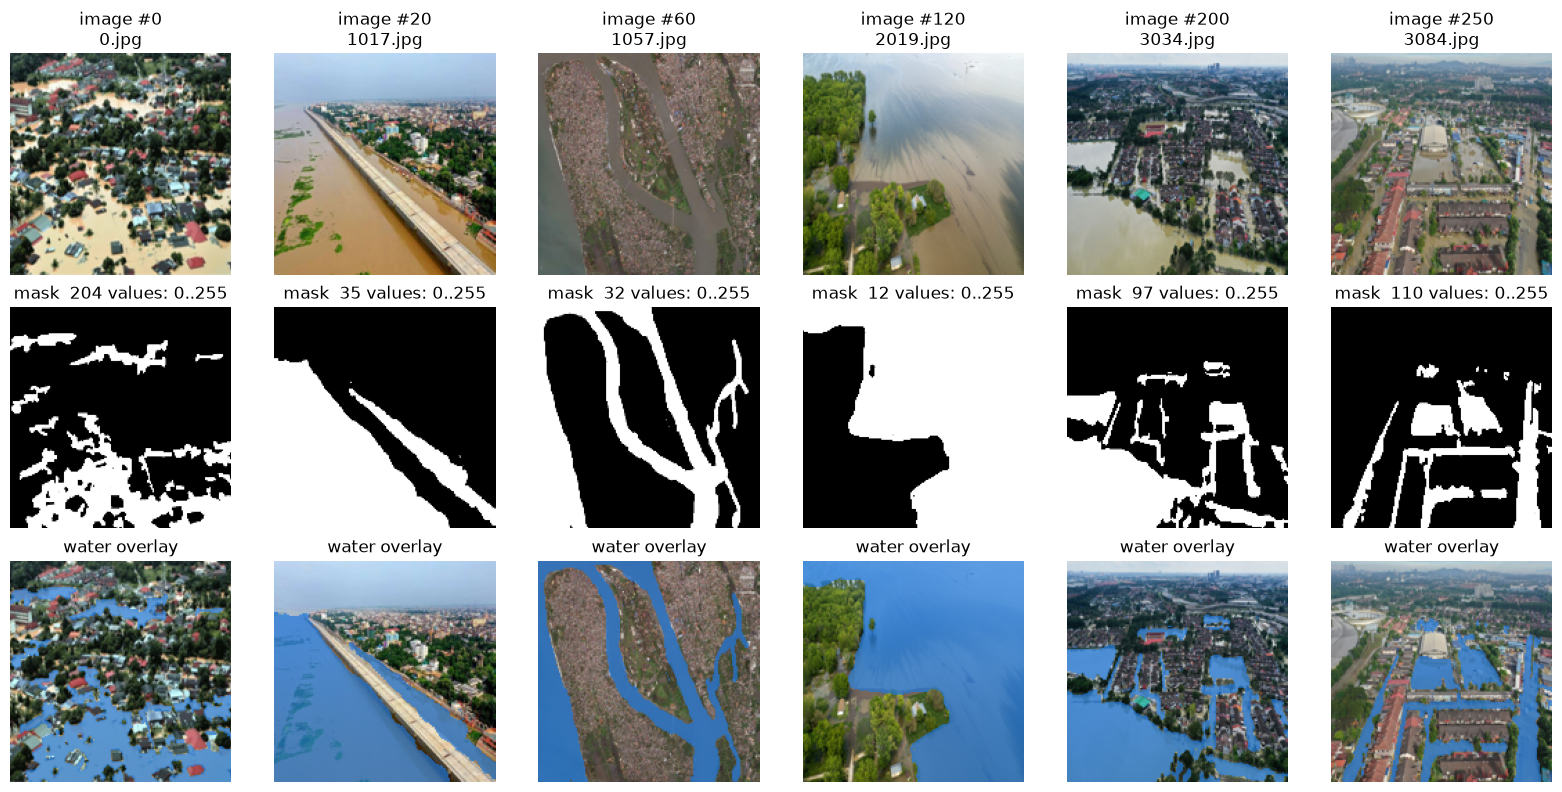


Mask values vary by file — some are (0, 1), some are (0, 255), some have anti-aliased edges like (0, 16, 63). The rule for ALL of them is the same: 0 = dry, any non-zero value = water. We'll threshold at > 0 → 1 in Section 2.1.
Total paired samples: 290


In [70]:
# Pick six indices and show image + mask + overlay for each.
pick = [0, 20, 60, 120, 200, 250]
pick = [i for i in pick if i < len(PAIRS)]  # defensive: dataset may be smaller

fig, axes = plt.subplots(3, len(pick), figsize=(16, 8))
for col, idx in enumerate(pick):
    img_path, mask_path = PAIRS[idx]
    img = Image.open(img_path).convert("RGB")
    msk = Image.open(mask_path).convert("L")

    # Resize to a common display size so columns align visually.
    img_disp = img.resize((160, 160))
    msk_disp = msk.resize((160, 160), Image.NEAREST)
    msk_arr = np.array(msk_disp)

    axes[0, col].imshow(img_disp)
    axes[0, col].set_title(f"image #{idx}\n{img_path.name}")
    axes[0, col].axis("off")

    axes[1, col].imshow(msk_arr, cmap="gray", vmin=0, vmax=255)
    uv = sorted(np.unique(msk_arr).tolist())
    uv_str = str(uv) if len(uv) <= 6 else f"{len(uv)} values: {uv[0]}..{uv[-1]}"
    axes[1, col].set_title(f"mask  {uv_str}")
    axes[1, col].axis("off")

    # Overlay: tint water pixels blue on top of the image.
    overlay = np.array(img_disp).copy()
    water = (msk_arr > 0)   # any non-zero pixel is water (dataset uses mixed value scales)
    overlay[water] = (0.3 * overlay[water] + 0.7 * np.array([30, 120, 220])).astype(np.uint8)
    axes[2, col].imshow(overlay, cmap="gray")
    axes[2, col].set_title("water overlay")
    axes[2, col].axis("off")

plt.tight_layout()
plt.show()

print(f"\nMask values vary by file — some are {0,1}, some are {0,255}, some have "
      f"anti-aliased edges like {0,16,63}. The rule for ALL of them is the same: "
      f"0 = dry, any non-zero value = water. We'll threshold at > 0 → 1 in Section 2.1.")
print(f"Total paired samples: {len(PAIRS)}")

## Section 2 — Core: five tasks  *(≈70 min)*

1. Wrap the file pairs so each item returns a resized `(image_tensor, binary_mask_tensor)` pair.
2. Build a `smp.Unet` with a pretrained ResNet-18 encoder — one line.
3. Pick a loss and a metric (BCE + IoU) and know what each one answers.
4. Write a training loop; train for 5 epochs.
5. Evaluate on the val subset and look at the best and worst predictions.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: خمس مهام *(نحو ٧٠ دقيقة)*

١. لُفَّ أزواج الملفّات لتُرجع كل عنصر زوجًا `(موتِّر صورة، موتِّر قناع ثنائي)` مُحجَّمًا.
٢. ابنِ `smp.Unet` بمُرمِّز `resnet18` مُدرَّب مسبقًا — سطر واحد.
٣. اختر خسارة ومقياسًا (BCE وIoU) واعرف ماذا يُجيب كلٌّ منهما.
٤. اكتب حلقة تدريب؛ دُرِّب ٥ حقب.
٥. قيِّم على مجموعة التحقّق وانظر إلى أفضل التنبّؤات وأسوئها.

</div>


### Task 2.1 — Pair every image with a clean binary mask

You have a list of `(image_path, mask_path)` pairs. The model wants two tensors:
`image` of shape `(3, H, W)` with ImageNet-normalised floats, and `mask` of shape
`(1, H, W)` with 0/1 values.

Write a `FloodSegDataset` class that holds the pairs and returns the pair of tensors.
The two transforms are different:
- **Image:** Resize to `(IMAGE_SIZE, IMAGE_SIZE)` with bilinear interpolation, ToTensor,
  Normalize with ImageNet statistics.
- **Mask:** Resize to the same shape with **nearest-neighbour** interpolation (so the
  label values stay integer, no 1.5s), then threshold `> 0` to get 0/1 floats (any non-zero pixel is water in this dataset).

**Why different interpolation?** Bilinear averages neighbours, which is right for pixel
intensities but wrong for class labels — averaging class 0 with class 1 would give you
0.5 that labels nothing. Nearest-neighbour picks the dominant class in each new
pixel's neighbourhood, which is right for a mask.

Then split the pairs 80/20 into train and val subsets, with a fixed seed.

<div dir="rtl" align="right">

### المهمة ٢٫١ — اقِرن كل صورة بقناع ثنائي نظيف

لديك قائمة من أزواج `(image_path, mask_path)`. والنموذج يريد موتِّرَين: `image`
بشكل `(3, H, W)` أعدادًا عشرية مُطبَّعة بإحصاءات ImageNet، و`mask` بشكل `(1, H, W)`
بقيم ٠/١.

اكتب صفًّا `FloodSegDataset` يحمل الأزواج ويُرجع زوج الموتِّرَين. والتحويلان مختلفان:
- **الصورة:** تحجيم إلى `(IMAGE_SIZE, IMAGE_SIZE)` بالاستكمال الثنائيّ الخطّي، ثم
  `ToTensor`، ثم `Normalize` بإحصاءات ImageNet.
- **القناع:** تحجيم إلى الشكل نفسه بالجوار **الأقرب** (ليبقى العنوان صحيحًا، بلا
  ٠٫٥)، ثم عتبة `> 0` للحصول على ٠/١ عشري.

**لماذا استكمالان مختلفان؟** يُعدِّل الثنائيّ الخطّي الجيران بالمتوسِّط، وهو صواب لشدّات
البكسل وخطأ لعناوين الفئات — فمتوسِّط الفئة ٠ والفئة ١ يعطيك ٠٫٥ لا تدلّ على فئة.
والجوار الأقرب يختار الفئة الأكثر شيوعًا في جوار كل بكسل جديد، وهو الصواب للقناع.

ثم قسِّم الأزواج ٨٠/٢٠ إلى مجموعتَي تدريب وتحقّق ببذرة ثابتة.

</div>


In [71]:
# ────────────────────────────────────────────────────────────────────
# 1) In __init__, store the pairs list and an image transform (Resize + ToTensor
#    + Normalize with [0.485,0.456,0.406] / [0.229,0.224,0.225]).
# 2) In __len__, return len(self.pairs).
# 3) In __getitem__, open both files with PIL, convert image to "RGB" and
#    mask to "L". Transform the image with self.image_tf. Resize the mask
#    with Image.NEAREST, convert to a tensor of 0/1 by thresholding at >0.
# 4) Return a (3, H, W) float tensor and a (1, H, W) float tensor.
# 5) Shuffle PAIRS with a fixed-seed numpy generator, then slice 80/20.
# Search: "pytorch custom Dataset image segmentation mask Resize NEAREST"
# https://pytorch.org/docs/stable/data.html
#
# ١) في `__init__`، احتفظ بقائمة الأزواج وتحويل الصورة (`Resize` + `ToTensor`
#    + `Normalize` بـ [0.485,0.456,0.406] / [0.229,0.224,0.225]).
# ٢) في `__len__`، أرجِع `len(self.pairs)`.
# ٣) في `__getitem__`، افتح الملفَّين بـPIL، وحوِّل الصورة إلى `"RGB"` والقناع
#    إلى `"L"`. وطبّق `self.image_tf` على الصورة. وحجِّم القناع بـ`Image.NEAREST`،
#    وحوِّله إلى موتِّر ٠/١ بعتبة `> 0` (أي بكسل غير صفري هو ماء).
# ٤) أرجِع موتِّرًا عشريًّا `(3, H, W)` وموتِّرًا عشريًّا `(1, H, W)`.
# ٥) اخلط `PAIRS` بمولِّد numpy ببذرة ثابتة، ثم قسِّم ٨٠/٢٠.
# ابحث عن: "pytorch custom Dataset image segmentation mask Resize NEAREST"
# https://pytorch.org/docs/stable/data.html
# ────────────────────────────────────────────────────────────────────

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
    # TODO: Build an image transform (Resize + ToTensor + Normalize) in __init__, and in __getitem__ apply it to the image and a nearest-resize + threshold-at-127 to the mask.
    # مهمة: ابنِ تحويل الصورة (`Resize` + `ToTensor` + `Normalize`) في `__init__`، وفي `__getitem__` طبّقه على الصورة، وطبّق تحجيم الجوار الأقرب والعتبة عند ١٢٧ على القناع.
class FloodSegDataset(Dataset):
    """Pairs of (image_tensor, binary_mask_tensor) from a list of file-path tuples."""

    def __init__(self, pairs):
        self.pairs = pairs

        self.image_tf = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=IMAGENET_MEAN,
                std=IMAGENET_STD
            )
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        image_path, mask_path = self.pairs[idx]

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = self.image_tf(image)

        mask = mask.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            Image.NEAREST
        )

        mask = np.array(mask)
        mask = (mask > 0).astype(np.float32)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask
rng = np.random.default_rng(42)
shuffled = PAIRS.copy(); rng.shuffle(shuffled)
split = int(len(shuffled) * 0.8)
train_pairs, val_pairs = shuffled[:split], shuffled[split:]
# TODO: Build train_set and val_set with the FloodSegDataset wrapper.
# مهمة: ابنِ `train_set` و`val_set` بلافّة `FloodSegDataset`.
train_set = FloodSegDataset(train_pairs)
val_set = FloodSegDataset(val_pairs)

### Task 2.2 — Build a U-Net with a pretrained encoder

One line of SMP gives you a complete U-Net:

```python
smp.Unet(encoder_name="resnet18", encoder_weights="imagenet", in_channels=3, classes=1)
```

What the arguments mean:
- `encoder_name="resnet18"` — the shrinking half is a ResNet-18 (the same architecture
  you used on D2). It has ~11M parameters that already know what edges and textures
  look like from ImageNet.
- `encoder_weights="imagenet"` — download those pretrained weights. Without this,
  the encoder starts random and you'd need thousands of images and many epochs.
- `in_channels=3` — RGB input.
- `classes=1` — the decoder outputs a 1-channel map (water probability per pixel).

Run `torchinfo.summary(model, input_size=(1, 3, 128, 128))` to see the shape journey:
input `(3, 128, 128)` → encoder shrinks to `(512, 4, 4)` → decoder grows back to
`(1, 128, 128)`.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — ابنِ U-Net بمُرمِّز مُدرَّب مسبقًا

سطرٌ واحد من SMP يعطيك U-Net كاملًا:

```python
smp.Unet(encoder_name="resnet18", encoder_weights="imagenet", in_channels=3, classes=1)
```

معاني الوسائط:
- `encoder_name="resnet18"` — النصف الذي يُصغِّر هو ResNet-18 (المعمارية نفسها
  التي استعملتَها في اليوم الثاني). فيه نحو ١١ مليون معامل تعرف أصلًا الحواف
  والمَلامس من ImageNet.
- `encoder_weights="imagenet"` — نزِّل تلك الأوزان المُدرَّبة. وبدونها، يبدأ المُرمِّز
  عشوائيًّا، فتحتاج آلاف الصور وحقبًا كثيرة.
- `in_channels=3` — دخل RGB.
- `classes=1` — يُخرج المُفكِّك خريطة قناة واحدة (احتمالية الماء لكل بكسل).

شغِّل `torchinfo.summary(model, input_size=(1, 3, 128, 128))` لرؤية رحلة الشكل: الدخل
`(3, 128, 128)` ← المُرمِّز يُصغّر إلى `(512, 4, 4)` ← المُفكِّك يُعيد إلى `(1, 128, 128)`.

</div>


In [72]:
# ────────────────────────────────────────────────────────────────────
# 1) Call smp.Unet(...) with the four arguments listed above.
# 2) Move the model to DEVICE immediately.
# 3) Run torchinfo.summary with input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE).
# 4) Check total params: ResNet-18 encoder (~11M) + decoder (~3M) ≈ 14M.
#
# ١) نادِ `smp.Unet(...)` بالوسائط الأربعة أعلاه.
# ٢) انقل النموذج إلى `DEVICE` مباشرة.
# ٣) شغّل `torchinfo.summary` بـ`input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE)`.
# ٤) تحقّق من إجمالي المعاملات: مُرمِّز ResNet-18 (نحو ١١ مليون) + مُفكِّك (نحو ٣ ملايين) ≈ ١٤ مليون.
# ────────────────────────────────────────────────────────────────────
# TODO: Build the U-Net with a resnet18 encoder pretrained on ImageNet, 3 input channels, 1 output class.
# مهمة: ابنِ U-Net بمُرمِّز `resnet18` مُدرَّب على ImageNet، و٣ قنوات دخل، وفئة خرج واحدة.
model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(DEVICE)

summary(
    model,
    input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE),
    col_names=("output_size", "num_params"),
    depth=2,
    device=DEVICE
)

TOTAL_PARAMS = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {TOTAL_PARAMS:,}")

Total parameters: 14,328,209


### Task 2.3 — Loss and metric

Two different things, often confused.

**Loss (`nn.BCEWithLogitsLoss`).** Binary cross-entropy with logits — pixel-by-pixel.
Because the mask is 0/1 and the model outputs one logit per pixel, this treats
segmentation as `128*128 = 16,384` independent binary classifications per image. It's
*smooth*, which gradient descent needs, and it combines sigmoid + BCE in one numerically
stable call.

We don't use cross-entropy here because that's for one-of-K choices across whole
classes. Here each pixel is its own binary question: *water, or not water?*

**Metric (IoU).** Intersection over Union, per image, averaged over the batch. For a
binary prediction `P` and ground truth `G`:
`IoU = (P ∧ G).sum() / (P ∨ G).sum()`

- IoU = 1.0 → the predicted flood mask matches the ground truth exactly.
- IoU = 0.5 → half the water is correctly caught, half is either missed or
  over-predicted on dry ground.
- IoU < 0.3 → the prediction barely overlaps with the actual water.

You use the **loss** to train (it has smooth gradients) and the **metric** to report
(it's what people quote).

<div dir="rtl" align="right">

### المهمة ٢٫٣ — الخسارة والمقياس

شيئان مختلفان، كثيرًا ما يُخلَط بينهما.

**الخسارة (`nn.BCEWithLogitsLoss`).** الإنتروبيا الثنائية باللوجيتات — بكسلًا بكسلًا.
ولأن القناع ٠/١ والنموذج يُخرج لوجيتًا واحدًا لكل بكسل، تعامل التجزئة بوصفها
`128*128 = 16٬384` تصنيفًا ثنائيًّا مستقلًّا للصورة. وهي *مُلسَّة*، وهو ما يحتاجه النزول
الاشتقاقي، وتجمع `sigmoid` مع BCE في نداء واحد مستقرّ عدديًّا.

ولا نستعمل cross-entropy هنا لأنها لاختيار واحد من K فئات كاملة. وهنا كل بكسل سؤاله
الثنائي الخاصّ: *ماء، أم ليس ماء؟*

**المقياس (IoU).** تقاطع على اتّحاد، لكل صورة، مُتوسَّطًا على الدفعة. لتنبّؤ ثنائي `P`
وحقيقة `G`:
`IoU = (P ∧ G).sum() / (P ∨ G).sum()`

- IoU = ١٫٠ ← يُطابق قناع الفيضان المتنبَّأ به الحقيقة تمامًا.
- IoU = ٠٫٥ ← نصف الماء مُدرَك بصواب، والنصف إمّا مفقود أو مُفرَط التنبّؤ به على أرض يابسة.
- IoU < ٠٫٣ ← التنبّؤ بالكاد يتقاطع مع الماء الحقيقي.

تستعمل **الخسارة** للتدريب (فتدرّجاتها مُلسَّة) و**المقياس** للتقرير (فهو الذي
يذكره الناس).

</div>


In [73]:
# ────────────────────────────────────────────────────────────────────
# 1) nn.BCEWithLogitsLoss() — no arguments, defaults are what we want.
# 2) Write iou_score(logits, mask, threshold=0.5): sigmoid the logits, threshold
#    them to 0/1, then compute intersection and union per image. Return the mean.
# 3) Use .float() for the sum, otherwise integer division happens.
# 4) Add a tiny epsilon (1e-6) to the denominator so empty masks don't crash.
# Search: "pytorch IoU intersection over union segmentation binary"
#
# ١) `nn.BCEWithLogitsLoss()` — بلا وسائط، الافتراضات هي ما نريد.
# ٢) اكتب `iou_score(logits, mask, threshold=0.5)`: طبّق `sigmoid` على اللوجيتات،
#    وعتِّبها إلى ٠/١، ثم احسب التقاطع والاتّحاد لكل صورة. وأرجِع المتوسِّط.
# ٣) استعمل `.float()` للمجموع، وإلا حدثت قسمة أعداد صحيحة.
# ٤) أضِف إبسيلون صغيرًا (١e−٦) إلى المقام لئلا تنهار الأقنعة الفارغة.
# ابحث عن: "pytorch IoU intersection over union segmentation binary"
# ────────────────────────────────────────────────────────────────────


criterion = nn.BCEWithLogitsLoss()
    # TODO: Sigmoid the logits, threshold them to 0/1, intersection/union per image, return the batch mean as a Python float.
    # مهمة: طبّق `sigmoid` على اللوجيتات، وعتِّبها إلى ٠/١، والتقاطع/الاتّحاد لكل صورة، وأرجِع متوسِّط الدفعة عددًا عشريًّا.
def iou_score(logits: torch.Tensor, mask: torch.Tensor, threshold: float = 0.5) -> float:

    probs = torch.sigmoid(logits)

    pred = (probs > threshold).float()

    inter = (pred * mask).sum(dim=(1, 2, 3))

    union = ((pred + mask) >= 1).float().sum(dim=(1, 2, 3))

    iou = torch.where(union == 0, torch.ones_like(union), inter / (union + 1e-6))

    return iou.mean().item()

dummy_mask = torch.zeros(2, 1, 16, 16); dummy_mask[0, 0, :8, :8] = 1

perfect_logits = (dummy_mask * 10 - 5)

print(f"perfect-prediction IoU: {iou_score(perfect_logits, dummy_mask):.3f}")

print(f"inverted-prediction IoU: {iou_score(-perfect_logits, dummy_mask):.3f}")

perfect-prediction IoU: 1.000
inverted-prediction IoU: 0.000


### Task 2.4 — Train for 5 epochs

The loop is the same shape as every training loop you've written: iterate batches,
forward, loss, backward, step; then a val pass with no_grad. The only new thing is
that `y` is a 4-D mask tensor instead of a 1-D label vector, and loss/metric work on
pixels instead of logits over classes.

Expect each epoch to take **~10 seconds on CPU** at 128×128 with batch 16 and the
pretrained encoder. Total ~1 minute for 5 epochs. Loss should fall from ~0.6 to ~0.2;
val IoU should rise from ~0.5 to ~0.75.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — دُرِّب ٥ حقب

الحلقة بالشكل نفسه الذي كتبته في كل تدريب: كرِّر على الدفعات، أماميّ، خسارة، خلفيّ،
خطوة؛ ثم تمريرة تحقّق بلا تدرّجات. والجديد الوحيد أن `y` موتِّر قناع رباعيّ البعد لا
متّجه عناوين، وأن الخسارة والمقياس يعملان على البكسلات لا على اللوجيتات فوق الفئات.

توقّع نحو **١٠ ثوانٍ لكل حقبة على CPU** عند ١٢٨×١٢٨ بدفعة ١٦ والمُرمِّز المُدرَّب
مسبقًا. والمجموع نحو دقيقة لـ٥ حقب. يجب أن تنزل الخسارة من نحو ٠٫٦ إلى نحو ٠٫٢،
وأن ترتفع دقّة IoU للتحقّق من نحو ٠٫٥ إلى نحو ٠٫٧٥.

</div>


  epoch 1/5  train loss 0.517  val IoU 0.576
  epoch 2/5  train loss 0.357  val IoU 0.637
  epoch 3/5  train loss 0.312  val IoU 0.529
  epoch 4/5  train loss 0.293  val IoU 0.522
  epoch 5/5  train loss 0.311  val IoU 0.656

finished in 40.9s | best val IoU: 0.656


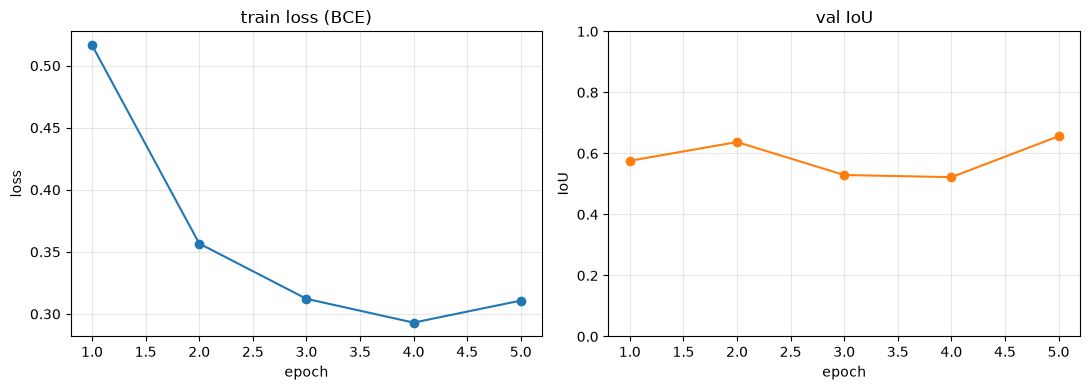

In [74]:
# ────────────────────────────────────────────────────────────────────
# 1) DataLoader(train_set, batch_size=16, shuffle=True) and same for val (no shuffle).
# 2) torch.optim.Adam(model.parameters(), lr=1e-3) — standard choice here.
# 3) Inside the epoch loop: model.train(), iterate batches, move to DEVICE,
#    forward, loss, backward, step. Accumulate loss / batch count.
# 4) Validation pass: model.eval() + torch.no_grad(), accumulate IoU per batch,
#    return the mean.
# 5) Keep train_losses and val_ious lists so you can plot them after.
# Search: "pytorch training loop binary segmentation BCEWithLogitsLoss"
#
# ١) `DataLoader(train_set, batch_size=16, shuffle=True)` ومثله للتحقّق (بلا خلط).
# ٢) `torch.optim.Adam(model.parameters(), lr=1e-3)` — الاختيار القياسي هنا.
# ٣) داخل حلقة الحقب: `model.train()`، كرِّر الدفعات، انقل إلى `DEVICE`،
#    أماميّ، خسارة، خلفيّ، خطوة. راكِم الخسارة / عدد الدفعات.
# ٤) تمريرة التحقّق: `model.eval()` + `torch.no_grad()`، راكِم IoU لكل دفعة،
#    أرجِع المتوسِّط.
# ٥) أبقِ قائمتَي `train_losses` و`val_ious` لرسمهما بعدًا.
# ابحث عن: "pytorch training loop binary segmentation BCEWithLogitsLoss"
import time
EPOCHS = 5      
BATCH_SIZE = 16 
LR = 1e-3 
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
train_losses, val_ious = [], []
t0 = time.perf_counter()
for epoch in range(EPOCHS):
    # TODO: Train pass — set train mode, iterate, forward/backward/step, accumulate loss.
    # مهمة: تمريرة تدريب — ضع الوضع، كرِّر، أماميّ/خلفيّ/خطوة، راكِم الخسارة.
    model.train()
    running_loss, n_batches = 0.0, 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        n_batches += 1
    train_losses.append(running_loss / n_batches)
    # TODO: Val pass — set eval mode, no_grad, accumulate IoU per batch, append the mean.
    # مهمة: تمريرة التحقّق — ضع وضع التقييم، بلا تدرّجات، راكِم IoU لكل دفعة، أضِف المتوسِّط.
    model.eval()
    running_iou, n_batches = 0.0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            running_iou += iou_score(logits, y)
            n_batches += 1
    val_ious.append(running_iou / n_batches)
    print(f"  epoch {epoch+1}/{EPOCHS}  "
          f"train loss {train_losses[-1]:.3f}  val IoU {val_ious[-1]:.3f}")

TRAIN_TIME = time.perf_counter() - t0
print(f"\nfinished in {TRAIN_TIME:.1f}s | best val IoU: {max(val_ious):.3f}")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(range(1, EPOCHS+1), train_losses, marker="o")
ax1.set_title("train loss (BCE)")
ax1.set_xlabel("epoch")
ax1.set_ylabel("loss")
ax1.grid(alpha=0.3)
ax2.plot(range(1, EPOCHS+1), val_ious, marker="o", color="C1")
ax2.set_title("val IoU")
ax2.set_xlabel("epoch")
ax2.set_ylabel("IoU")
ax2.set_ylim(0, 1)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Task 2.5 — Best three, worst three

A single IoU number across the val set hides a lot. For every val image, compute its
IoU, then sort. Display the top 3 and bottom 3 as `original | ground truth | prediction`.

Look at the worst three and write a one-sentence failure mode for each in
`FAILURE_MODES`. Common ones for flood photos:
- **reflections** — tree reflections in water confuse the model
- **wet pavement vs flood** — rain-wet roads look like shallow flooding
- **shadows** — dark shadows get predicted as water
- **flooded building roofs** — not visible from street level, model misses them
- **small puddles** — the annotator marked tiny isolated water pools the model smooths over

<div dir="rtl" align="right">

### المهمة ٢٫٥ — الأفضل ثلاثة والأسوأ ثلاثة

رقم IoU واحد عبر مجموعة التحقّق يُخفي الكثير. لكل صورة تحقّق، احسب IoU الخاصّ بها،
ثم رتِّب. اعرض الأفضل ٣ والأسوأ ٣ بصيغة `أصلي | حقيقي | تنبّؤ`.

انظر إلى الأسوأ الثلاثة واكتب جملة لنمط الفشل لكلٍّ منها في `FAILURE_MODES`. الشائعة
في صور الفيضانات:
- **انعكاسات** — انعكاسات الأشجار في الماء تربك النموذج
- **رصيف مبلّل مقابل فيضان** — الطرقات المبلّلة من المطر تبدو كفيضان ضحل
- **ظلال** — الظلال الداكنة تُتوقَّع بوصفها ماء
- **أسطح مبانٍ مغمورة** — غير مرئية من مستوى الشارع، فيُفوّتها النموذج
- **برك صغيرة** — المعلِّق علّم برك ماء صغيرة معزولة لا يُدركها النموذج

</div>


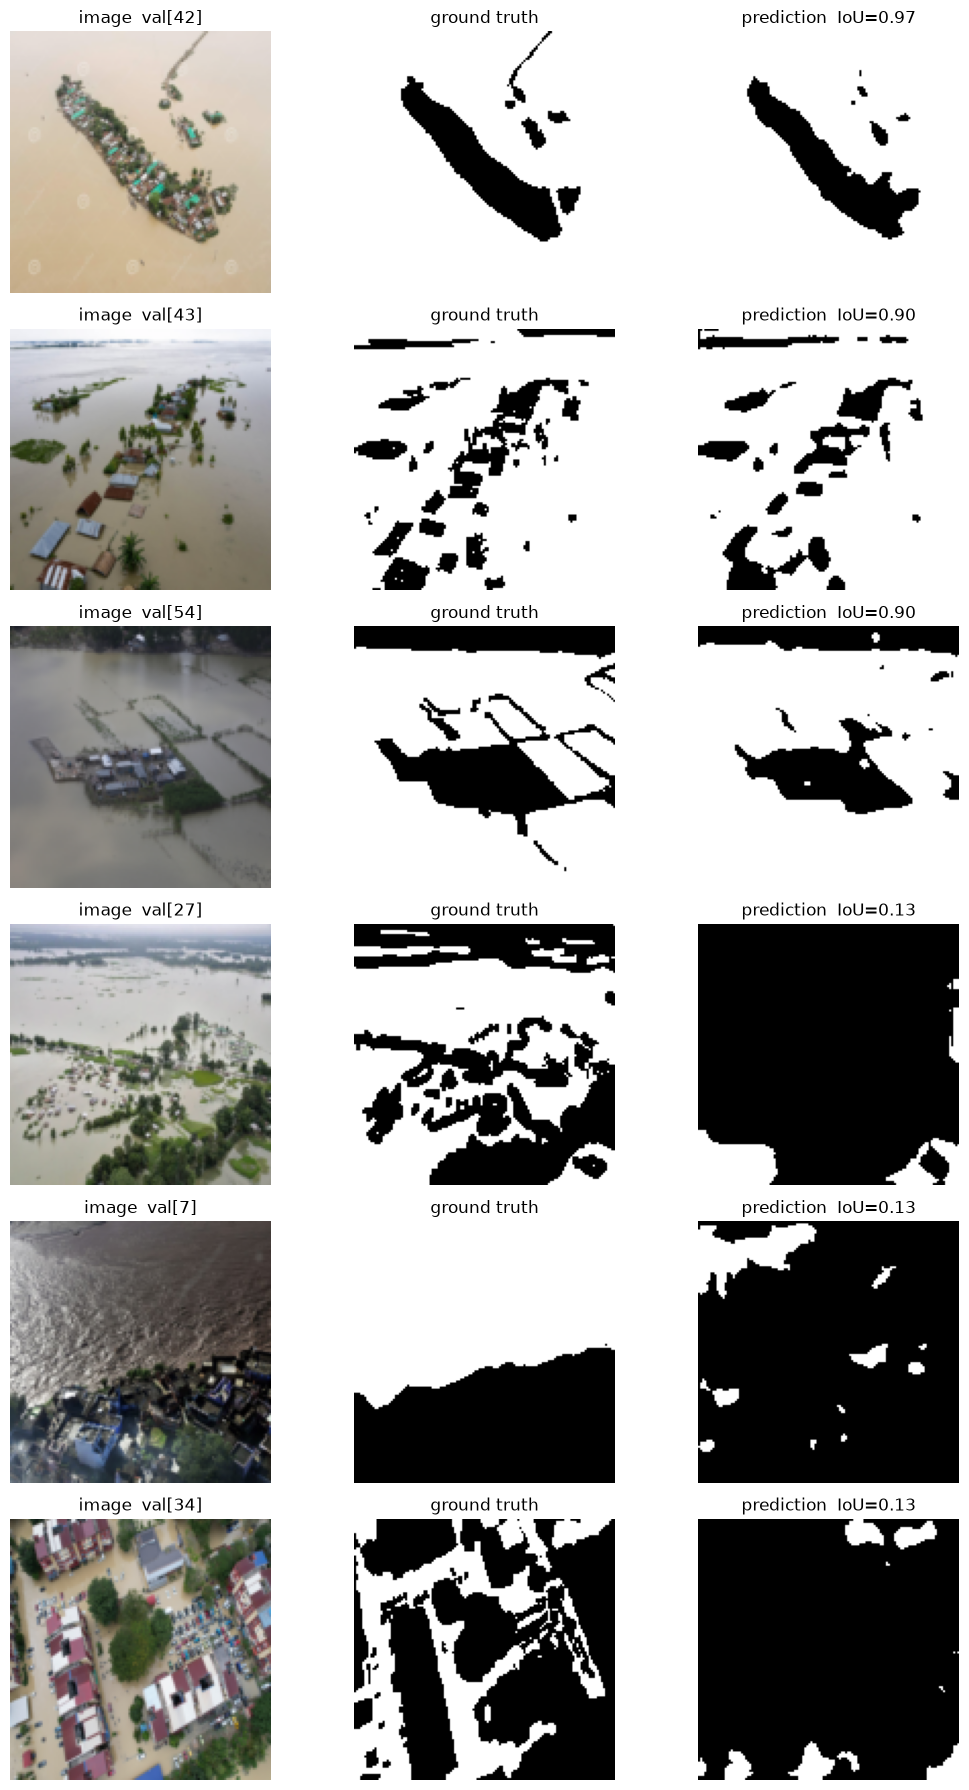


best 3 IoU:  [0.9, 0.9, 0.97]
worst 3 IoU: [0.13, 0.13, 0.13]
  val[27]: The model over-predicts flood water across buildings and dry land....
  val[7]: Dark textured terrain is incorrectly predicted as a large flooded area...
  val[34]: Buildings, roads, and shadows are incorrectly predicted as flood water...


In [75]:
# ────────────────────────────────────────────────────────────────────
# 1) Loop over val_set with no_grad, compute per-image IoU with iou_score on
#    a batch of 1, collect (idx, iou) pairs.
# 2) Sort by iou; take [:3] and [-3:] for worst/best.
# 3) To un-normalise an image for display: img * std + mean, clip to [0,1].
# 4) Fill FAILURE_MODES with one short reason per worst case.
#
# ١) كرِّر على `val_set` بلا تدرّجات، احسب IoU لكل صورة بـ`iou_score` على
#    دفعة من ١، واجمع أزواج `(idx, iou)`.
# ٢) رتِّب بـ`iou`؛ خذ `[:3]` و`[-3:]` للأسوأ والأفضل.
# ٣) لإلغاء تطبيع الصورة للعرض: `img * std + mean`، واقتطع إلى [٠،١].
# ٤) املأ `FAILURE_MODES` بسبب واحد قصير لكل حالة سيئة.
# ────────────────────────────────────────────────────────────────────

# TODO: Build a list of (val_set_index, iou) tuples by running model one image at a time.
# مهمة: ابنِ قائمة أزواج `(val_set_index, iou)` بتشغيل النموذج على صورة واحدة في المرّة.
model.eval()
per_image_ious = []
with torch.no_grad():
    for idx in range(len(val_set)):
        img, mask = val_set[idx]
        logits = model(img[None].to(DEVICE))
        iou = iou_score(logits, mask[None].to(DEVICE))
        per_image_ious.append((idx, iou))
per_image_ious.sort(key=lambda x: x[1])
worst3 = per_image_ious[:3]
best3 = per_image_ious[-3:]
def un_normalise(t: torch.Tensor) -> np.ndarray:
    """Reverse ImageNet normalisation on a (3, H, W) tensor for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
def show_row(ax_row, idx, iou):
    img, msk = val_set[idx]
    with torch.no_grad():
        pred = torch.sigmoid(model(img[None].to(DEVICE)))[0, 0].cpu() > 0.5
    ax_row[0].imshow(un_normalise(img))
    ax_row[0].set_title(f"image  val[{idx}]")
    ax_row[1].imshow(msk[0], cmap="gray")
    ax_row[1].set_title("ground truth")
    ax_row[2].imshow(pred, cmap="gray")
    ax_row[2].set_title(f"prediction  IoU={iou:.2f}")
    for ax in ax_row:
        ax.axis("off")
fig, axes = plt.subplots(6, 3, figsize=(11, 18))
for row, (idx, iou) in enumerate(best3[::-1]):
    show_row(axes[row], idx, iou)
    axes[row, 0].set_ylabel("BEST", fontsize=12, rotation=0, labelpad=30)
for row, (idx, iou) in enumerate(worst3):
    show_row(axes[row + 3], idx, iou)
    axes[row + 3, 0].set_ylabel("WORST", fontsize=12, rotation=0, labelpad=30)
plt.tight_layout()
plt.show()
    # TODO: One short reason per worst case, naming what you see in that image.
    # مهمة: جملة سبب قصيرة لكل حالة سيئة، تسمّي ما تراه في تلك الصورة.
FAILURE_MODES = {
    "val[27]": "The model over-predicts flood water across buildings and dry land.",
    "val[7]": "Dark textured terrain is incorrectly predicted as a large flooded area.",
    "val[34]": "Buildings, roads, and shadows are incorrectly predicted as flood water."
}
print(f"\nbest 3 IoU:  {[round(i, 2) for _, i in best3]}")
print(f"worst 3 IoU: {[round(i, 2) for _, i in worst3]}")
for k, v in FAILURE_MODES.items():
    print(f"  {k}: {v[:70]}...")

## Section 3 — Stretch *(≈25 min)*

Two open tasks. The first swaps the loss and asks whether it matters. The second
re-uses D1's augmentation lesson in a segmentation context — and reveals a trap
specific to segmentation that D1's binary classifier doesn't have.

<div dir="rtl" align="right">

## القسم الثالث — إضافي *(نحو ٢٥ دقيقة)*

مهمّتان مفتوحتان. الأولى تستبدل الخسارة وتسأل: هل الفرق حقيقيّ؟ والثانية تُعيد استعمال
درس تكثير اليوم الأول في سياق التجزئة — وتكشف مصيدة خاصّة بالتجزئة لا توجد في مصنِّف
اليوم الأول الثنائي.

</div>


### Stretch A — Dice loss, same U-Net

BCE treats every pixel independently. **Dice loss** rewards *overlap* directly — it is
basically `1 - IoU` with a differentiable surrogate — which can help when the water
is a small fraction of the image (because BCE's dry-ground pixels dominate the
gradient when water is sparse).

Train the identical U-Net for the same 5 epochs with `smp.losses.DiceLoss(mode="binary")`
instead of `BCEWithLogitsLoss`. Report the final val IoU. On this dataset the two
often land within a point of each other — the lesson is that the loss matters less
than the pretrained encoder, as long as it isn't completely wrong.

<div dir="rtl" align="right">

### الإضافي أ — خسارة Dice، على U-Net نفسها

تعامل BCE كل بكسل مستقلًّا. و**خسارة Dice** تُكافئ *التداخل* مباشرة — فهي أساسًا
`1 - IoU` بديلًا قابلًا للاشتقاق — ويمكن أن تنفع حين يكون الماء جزءًا صغيرًا من الصورة
(لأن بكسلات الأرض اليابسة في BCE تهيمن على التدرّج حين يكون الماء شحيحًا).

درِّب U-Net نفسها للخمس حقب نفسها بـ`smp.losses.DiceLoss(mode="binary")` بدل
`BCEWithLogitsLoss`. اعرض IoU النهائي للتحقّق. وعلى هذه البيانات غالبًا تنزل الاثنتان
في نقطة واحدة — والدرس أن الخسارة أقلّ أهمية من المُرمِّز المُدرَّب مسبقًا، ما لم تكن
خاطئة تمامًا.

</div>


In [76]:
# ────────────────────────────────────────────────────────────────────
# 1) Rebuild a fresh model (seed_everything first) so the encoder weights
#    don't carry over from the BCE run.
# 2) smp.losses.DiceLoss(mode="binary") is the only change; everything else
#    is identical to Task 2.4.
# 3) Report dice_final_iou and compare with max(val_ious) from the BCE run.
#
# ١) أعِد بناء نموذج جديد (`seed_everything` أولًا) حتى لا تحمل أوزان المُرمِّز
#    من تشغيل BCE.
# ٢) `smp.losses.DiceLoss(mode="binary")` هو التغيير الوحيد؛ كل شيء آخر مطابق
#    للمهمة ٢٫٤.
# ٣) اعرض `dice_final_iou` وقارنه بـ`max(val_ious)` من تشغيل BCE.
# ────────────────────────────────────────────────────────────────────

# TODO: Rebuild the model with the same encoder, train for EPOCHS epochs with Dice loss, and record dice_final_iou = best val IoU of this run.
# مهمة: أعِد بناء النموذج بالمُرمِّز نفسه، ودرِّب EPOCHS حقبة بخسارة Dice، وسجِّل `dice_final_iou` = أفضل IoU تحقّق لهذه التشغيلة.
seed_everything(42)
dice_model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(DEVICE)
dice_criterion = smp.losses.DiceLoss(mode="binary")
dice_optimizer = torch.optim.Adam(
    dice_model.parameters(),
    lr=LR
)
dice_val_ious = []
for epoch in range(EPOCHS):
    dice_model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        dice_optimizer.zero_grad()
        logits = dice_model(x)
        loss = dice_criterion(logits, y)
        loss.backward()
        dice_optimizer.step()
    dice_model.eval()
    running_iou, n_batches = 0.0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = dice_model(x)
            running_iou += iou_score(logits, y)
            n_batches += 1
    dice_val_ious.append(running_iou / n_batches)
    print(
        f"  epoch {epoch+1}/{EPOCHS}  "
        f"val IoU {dice_val_ious[-1]:.3f}"
    )
dice_final_iou = max(dice_val_ious)
print(f"\n  BCE best val IoU:   {max(val_ious):.3f}")
print(f"  Dice best val IoU:  {dice_final_iou:.3f}")
print(f"  gap:  {dice_final_iou - max(val_ious):+.3f}")

  epoch 1/5  val IoU 0.394
  epoch 2/5  val IoU 0.611
  epoch 3/5  val IoU 0.685
  epoch 4/5  val IoU 0.706
  epoch 5/5  val IoU 0.634

  BCE best val IoU:   0.656
  Dice best val IoU:  0.706
  gap:  +0.050


### Stretch B — Augmentation for segmentation (the joint-transform trap)

In D1 you used `RandomHorizontalFlip` on image classification and it worked out of
the box. In segmentation it almost works — but has a trap. When you flip an image,
you **must flip the mask the same way**, or the model learns to predict water where
it doesn't exist.

**The wrong way (silent bug):** apply the transform to the image only. The model's
loss drops because the water pixels moved, but the ground truth it's compared against
didn't move — so the network trains against a scrambled target and val IoU collapses.

**The right way:** apply the same transform to both image and mask, in sync. The
simplest trick is to use the same random seed for both calls. A more robust pattern
is to pre-decide the random choice (flip? rotate by how much?) and then apply it
deterministically to both.

Train once with the correct joint augmentation (horizontal flip only, p=0.5) and
compare the final val IoU to the no-aug baseline from Task 2.4. Expect a small
improvement — this dataset is small enough that even one careful augmentation helps.

<div dir="rtl" align="right">

### الإضافي ب — التكثير للتجزئة (مصيدة التحويل المشترك)

في اليوم الأول استعملتَ `RandomHorizontalFlip` على تصنيف الصور وعمل مباشرة. أمّا في
التجزئة فيكاد يعمل — لكن فيه مصيدة. حين تقلب صورة، **يجب أن تقلب القناع الطريقة
نفسها**، وإلا تعلّم النموذج أن يتنبّأ بماء حيث لا يوجد.

**الطريقة الخاطئة (خطأ صامت):** تطبيق التحويل على الصورة فقط. تنزل خسارة النموذج لأن
بكسلات الماء تحرّكت، لكن الحقيقة التي يُقارَن بها لم تتحرّك — فتُدرَّب الشبكة على
هدف مشوَّش وتنهار IoU التحقّق.

**الطريقة الصحيحة:** تطبيق التحويل نفسه على الصورة والقناع معًا بتناسق. أبسط حيلة
استعمال البذرة العشوائية نفسها للنداءَين. والنمط الأمتن أن تقرِّر الاختيار العشوائي
مسبقًا (أقلب؟ أدور بكم؟) ثم تطبّقه حتميًّا على كليهما.

درِّب مرّة بالتكثير المشترك الصحيح (قلب أفقيّ فقط، p=٠٫٥) وقارن IoU النهائي للتحقّق
بأساس اليوم في المهمة ٢٫٤. توقّع تحسّنًا طفيفًا — هذه المجموعة صغيرة بما يكفي ليفيد
تكثير واحد حذِر.

</div>


In [77]:
# ────────────────────────────────────────────────────────────────────
# 1) Make a new dataset subclass FloodSegAugDataset that, in __getitem__, decides
#    one random bool (flip or not) and applies it to BOTH image and mask after
#    the normal transforms.
# 2) Use torch.rand(()).item() or np.random.random() for the decision — then
#    just torch.flip(tensor, dims=[-1]) for the horizontal flip on each.
# 3) Rebuild model (seed_everything first), train for EPOCHS epochs on the aug
#    train set, evaluate on the original val set (NEVER augment val).
# 4) Report aug_final_iou and compare with max(val_ious).
#
# ١) اصنع صفًّا جديدًا `FloodSegAugDataset` يُقرِّر في `__getitem__` قيمة بوليانية
#    عشوائية واحدة (أقلب أو لا) ويُطبِّقها على **كليهما** الصورة والقناع بعد التحويلات
#    الاعتيادية.
# ٢) استعمل `torch.rand(()).item()` أو `np.random.random()` للقرار — ثم
#    `torch.flip(tensor, dims=[-1])` للقلب الأفقيّ على كلٍّ منهما.
# ٣) أعِد بناء النموذج (`seed_everything` أولًا)، درِّب EPOCHS على مجموعة التدريب
#    المكثَّرة، وقيِّم على مجموعة التحقّق الأصلية (لا تُكثِّر التحقّق أبدًا).
# ٤) اعرض `aug_final_iou` وقارنه بـ`max(val_ious)`.
# ────────────────────────────────────────────────────────────────────

# TODO: Build FloodSegAugDataset with joint horizontal flip, train once, report best IoU.
# مهمة: ابنِ `FloodSegAugDataset` بقلب أفقيّ مشترك، درِّب مرّة، واعرض أفضل IoU.
class FloodSegAugDataset(FloodSegDataset):
    def __getitem__(self, idx):
        img, mask = super().__getitem__(idx)
        if torch.rand(()).item() < 0.5:
            img = torch.flip(img, dims=[-1])
            mask = torch.flip(mask, dims=[-1])
        return img, mask
seed_everything(42)
aug_train_set = FloodSegAugDataset(train_pairs)
aug_train_loader = DataLoader(
    aug_train_set,
    batch_size=BATCH_SIZE,
    shuffle=True
)
aug_model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(DEVICE)
aug_optimizer = torch.optim.Adam(
    aug_model.parameters(),
    lr=LR
)
aug_val_ious = []
for epoch in range(EPOCHS):
    aug_model.train()
    for x, y in aug_train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        aug_optimizer.zero_grad()
        logits = aug_model(x)
        loss = criterion(logits, y)
        loss.backward()
        aug_optimizer.step()
    aug_model.eval()
    running_iou, n_batches = 0.0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = aug_model(x)
            running_iou += iou_score(logits, y)
            n_batches += 1
    aug_val_iou = running_iou / n_batches
    aug_val_ious.append(aug_val_iou)
    print(
        f"  epoch {epoch+1}/{EPOCHS}  "
        f"val IoU {aug_val_iou:.3f}"
    )
aug_final_iou = max(aug_val_ious)
print(f"\n  no-aug best val IoU:   {max(val_ious):.3f}")
print(f"  with-aug best val IoU: {aug_final_iou:.3f}")
print(f"  gap:  {aug_final_iou - max(val_ious):+.3f}  (positive = joint-flip augmentation helped)")

  epoch 1/5  val IoU 0.555
  epoch 2/5  val IoU 0.616
  epoch 3/5  val IoU 0.645
  epoch 4/5  val IoU 0.636
  epoch 5/5  val IoU 0.674

  no-aug best val IoU:   0.656
  with-aug best val IoU: 0.674
  gap:  +0.018  (positive = joint-flip augmentation helped)


## Save your artefact

`unet_check.json` holds what tomorrow can check against: model parameter count,
training time, final loss and IoU, the Dice-loss comparison, and the augmentation gap.

<div dir="rtl" align="right">

## احفظ أثرك

يحفظ `unet_check.json` ما يستطيع الغد التحقّق منه: عدد معاملات النموذج، وزمن التدريب،
والخسارة النهائية وIoU، ومقارنة خسارة Dice، وفجوة التكثير.

</div>


In [78]:
import json

unet_check = {
    "image_size": IMAGE_SIZE,
    "total_pairs": len(PAIRS),
    "train_size": len(train_set),
    "val_size":   len(val_set),
    "model_params": TOTAL_PARAMS,
    "epochs": EPOCHS,
    "train_losses": [round(float(x), 4) for x in train_losses],
    "val_ious":     [round(float(x), 4) for x in val_ious],
    "best_val_iou": round(float(max(val_ious)), 4),
    "train_seconds": round(TRAIN_TIME, 1),
    "dice_best_val_iou":  round(float(dice_final_iou), 4),
    "aug_best_val_iou":   round(float(aug_final_iou), 4),
    "failure_modes": FAILURE_MODES,
}

path = ARTEFACT_DIR / "unet_check.json"
path.write_text(json.dumps(unet_check, indent=2))
print(f"wrote {path}")
print(json.dumps(unet_check, indent=2))

wrote /Users/fahad/Desktop/AIEP/AIEP_Olo_student_Fahad/week_4_cnn_finetuning/labs/D3_segmentation_unet/artefacts/unet_check.json
{
  "image_size": 128,
  "total_pairs": 290,
  "train_size": 232,
  "val_size": 58,
  "model_params": 14328209,
  "epochs": 5,
  "train_losses": [
    0.5165,
    0.3567,
    0.3122,
    0.293,
    0.3108
  ],
  "val_ious": [
    0.5758,
    0.6372,
    0.5292,
    0.5222,
    0.6562
  ],
  "best_val_iou": 0.6562,
  "train_seconds": 40.9,
  "dice_best_val_iou": 0.7063,
  "aug_best_val_iou": 0.6744,
  "failure_modes": {
    "val[27]": "The model over-predicts flood water across buildings and dry land.",
    "val[7]": "Dark textured terrain is incorrectly predicted as a large flooded area.",
    "val[34]": "Buildings, roads, and shadows are incorrectly predicted as flood water."
  }
}


## Sanity check

<div dir="rtl" align="right">

## فحص السلامة

</div>


In [79]:
check(TOTAL_PARAMS > 10_000_000 and TOTAL_PARAMS < 20_000_000,
      f"U-Net with a resnet18 encoder should have 10–20M params — got {TOTAL_PARAMS:,}",
      f"U-Net بمُرمِّز `resnet18` ينبغي أن يملك ١٠–٢٠ مليون معامل — والناتج {TOTAL_PARAMS:,}")

check(train_losses[-1] < train_losses[0],
      f"training loss should decrease across epochs — got {train_losses[0]:.3f} → "
      f"{train_losses[-1]:.3f}",
      f"يجب أن تنخفض خسارة التدريب عبر الحقب — والناتج {train_losses[0]:.3f} ← "
      f"{train_losses[-1]:.3f}")

check(max(val_ious) > 0.50,
      f"best val IoU should exceed 0.50 with a pretrained encoder — got {max(val_ious):.3f}",
      f"يجب أن يتجاوز أفضل IoU تحقّق ٠٫٥٠ بمُرمِّز مُدرَّب مسبقًا — والناتج {max(val_ious):.3f}")

check(abs(dice_final_iou - max(val_ious)) < 0.20,
      f"Dice and BCE should land within 20 points of each other on this dataset — "
      f"BCE {max(val_ious):.3f}, Dice {dice_final_iou:.3f}",
      f"يجب أن تنزل Dice وBCE في ٢٠ نقطة من بعضهما على هذه البيانات — "
      f"BCE {max(val_ious):.3f}، Dice {dice_final_iou:.3f}")

check(aug_final_iou > max(val_ious) - 0.10,
      f"augmented run should land within 10 points of (and ideally above) the no-aug "
      f"baseline — no-aug {max(val_ious):.3f}, aug {aug_final_iou:.3f}. If much lower, "
      f"your joint-flip isn't actually joint and the mask is misaligned.",
      f"يجب أن تنزل التشغيلة المكثَّرة في ١٠ نقاط من الأساس بلا تكثير (ومفضَّل فوقه) — "
      f"بلا تكثير {max(val_ious):.3f}، مكثَّر {aug_final_iou:.3f}. إن كان أدنى بكثير فقلبك "
      f"المشترك ليس مشتركًا فعلًا والقناع غير محاذٍ.")

check(all(len(v.split()) >= 8 for v in FAILURE_MODES.values()),
      f"write a real reason (8+ words) for each of the three worst cases — got "
      f"{ {k: len(v.split()) for k, v in FAILURE_MODES.items()} } words",
      f"اكتب سببًا حقيقيًّا (٨ كلمات فأكثر) لكل حالة من الحالات الثلاث السيئة، والعدد الحالي "
      f"{ {k: len(v.split()) for k, v in FAILURE_MODES.items()} }")

report()

──────────────────────────────────────────────────────────────────
  ✓  U-Net with a resnet18 encoder should have 10–20M params — got 14,328,209
  ✓  training loss should decrease across epochs — got 0.517 → 0.311
  ✓  best val IoU should exceed 0.50 with a pretrained encoder — got 0.656
  ✓  Dice and BCE should land within 20 points of each other on this dataset — BCE 0.656, Dice 0.706
  ✓  augmented run should land within 10 points of (and ideally above) the no-aug baseline — no-aug 0.656, aug 0.674. If much lower, your joint-flip isn't actually joint and the mask is misaligned.
  ✓  write a real reason (8+ words) for each of the three worst cases — got {'val[27]': 10, 'val[7]': 11, 'val[34]': 10} words
──────────────────────────────────────────────────────────────────
  ✅ All 6 checks passed. / اجتزت جميع الفحوصات (6).
──────────────────────────────────────────────────────────────────


## What's next

Today you built a per-pixel classifier. Tomorrow you build a per-object detector:
same CNN backbone, but the output changes shape yet again.

| Day | Output | Architecture |
|---|---|---|
| D1 | one label per image | small CNN |
| D2 | one label per image, from a pretrained net | ResNet-18 fine-tune |
| **D3** (today) | **one label per pixel** | **U-Net** |
| **D4** (tomorrow) | **one box + label per object** | **YOLO** |
| D5 | — | (recap / project time) |

The pattern should start to feel clear: the backbone is almost always the same,
and the architecture is defined by what you glue on at the end — a classifier head,
a decoder, or a detection head.

<div dir="rtl" align="right">

## ما التالي

اليوم بنيتَ مصنِّفًا على مستوى البكسل. غدًا تبني كاشفًا على مستوى الكائن: العمود
الفقري الالتفافي نفسه، لكن الخرج يُغيِّر شكله مرّة أخرى.

| اليوم | الخرج | المعمارية |
|---|---|---|
| اليوم ١ | عنوان لكل صورة | شبكة صغيرة |
| اليوم ٢ | عنوان لكل صورة من شبكة مُدرَّبة | ضبط ResNet-18 |
| **اليوم ٣** (اليوم) | **عنوان لكل بكسل** | **U-Net** |
| **اليوم ٤** (غدًا) | **صندوق + عنوان لكل كائن** | **YOLO** |
| اليوم ٥ | — | (استذكار / وقت المشروع) |

النمط يبدأ أن يصير واضحًا: العمود الفقري دائمًا هو نفسه، والمعمارية تُعرَّف بما
تُلصقه في النهاية — رأس تصنيف، أو مُفكِّك، أو رأس كشف.

</div>
